In [2]:

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:

# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:

# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [8]:

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [9]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [10]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [39]:
C = torch.randn((27, 5))



In [40]:
C

tensor([[ 2.2980,  1.7142,  1.2739,  0.9014,  0.1065],
        [ 0.8963,  0.9596,  0.5446,  0.4051, -0.0524],
        [ 2.1340,  1.0260,  0.0459,  0.8275,  0.3972],
        [ 0.6595, -0.3073, -0.4496, -0.7267,  0.2512],
        [-1.2326, -0.0060, -2.1802, -0.8606,  0.2058],
        [ 0.3772, -0.7554, -0.9606, -1.6179, -0.2135],
        [ 0.6657,  0.2562, -0.8927,  0.1990, -0.2920],
        [-0.1163,  0.3843, -1.6740, -0.7148, -0.2243],
        [-0.4236, -0.2967,  0.2747, -1.0890,  0.8423],
        [-0.8611,  1.2155,  1.0025, -0.2497, -0.9908],
        [-0.7506,  1.2443,  2.0035,  1.1653,  0.4270],
        [ 0.9674, -1.6026,  1.2313,  0.1000, -0.9359],
        [ 1.7929, -1.2577, -1.2243, -0.9432, -0.1334],
        [ 1.6856, -0.3358,  0.9357,  1.1419,  1.2478],
        [ 0.5208,  0.8809, -1.3000,  0.7212,  0.2757],
        [ 0.2303,  0.4368,  0.3611,  0.1144, -1.9208],
        [-2.1168, -1.2871,  0.2294,  0.6270,  0.0217],
        [-1.5952, -1.2868, -0.2551, -0.2651, -0.7470],
        [ 

In [43]:
Xdev[:2,]

tensor([[0, 0, 0],
        [0, 0, 1]])

In [ ]:
emb = C[Xdev]
emb.shape

torch.Size([22655, 3, 5])

In [47]:
W1 = torch.randn((15, 100))
b1 = torch.randn(100)

In [50]:
h = torch.tanh(emb.view(-1,15) @ W1 + b1)
h.shape

torch.Size([22655, 100])

In [51]:

W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [52]:

logits = h @ W2 + b2

In [56]:

counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
prob.shape

torch.Size([22655, 27])

In [67]:
Y.min(), Y.max()

(tensor(0), tensor(26))

In [71]:
Y[:2 ]

tensor([ 5, 13])

In [72]:
prob[:2,]

tensor([[3.2983e-05, 6.0120e-05, 1.1392e-07, 8.0428e-07, 8.4163e-06, 1.9380e-08,
         1.8976e-12, 2.8014e-04, 5.3025e-07, 9.3715e-01, 2.0334e-06, 3.0244e-04,
         4.5306e-05, 1.5087e-13, 1.0225e-02, 8.8690e-09, 4.3646e-02, 4.4154e-04,
         1.1227e-06, 2.3633e-04, 2.1198e-07, 2.1646e-09, 4.7287e-05, 2.3709e-09,
         7.7681e-07, 2.4558e-06, 7.5201e-03],
        [2.5882e-08, 9.2044e-01, 4.0090e-06, 1.8926e-11, 5.9036e-06, 8.6448e-07,
         3.6128e-11, 8.0040e-06, 9.9518e-08, 6.6877e-02, 3.1542e-06, 2.1256e-03,
         1.1002e-07, 2.0222e-14, 2.2176e-04, 9.2683e-07, 2.4349e-05, 6.1031e-06,
         1.0499e-10, 4.7151e-07, 3.0425e-12, 3.4319e-11, 1.6264e-06, 4.6072e-09,
         4.1293e-07, 2.2881e-08, 1.0276e-02]])

In [74]:
prob.shape

torch.Size([22655, 27])

In [77]:
loss = F.cross_entropy(prob, Ydev)
loss

tensor(3.2828)

In [81]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [82]:
C.shape

torch.Size([27, 10])

In [83]:

sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [84]:

for p in parameters:
  p.requires_grad = True

In [85]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [86]:
lri = []
lossi = []
stepi = []

In [87]:
for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

In [91]:
print(loss.item())

2.5694873332977295


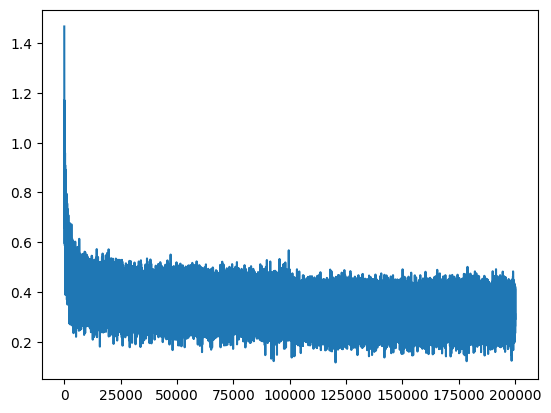

In [92]:
plt.plot(stepi, lossi)

In [99]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1148, grad_fn=<NllLossBackward0>)

In [101]:

emb = C[Xte] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.1534, grad_fn=<NllLossBackward0>)

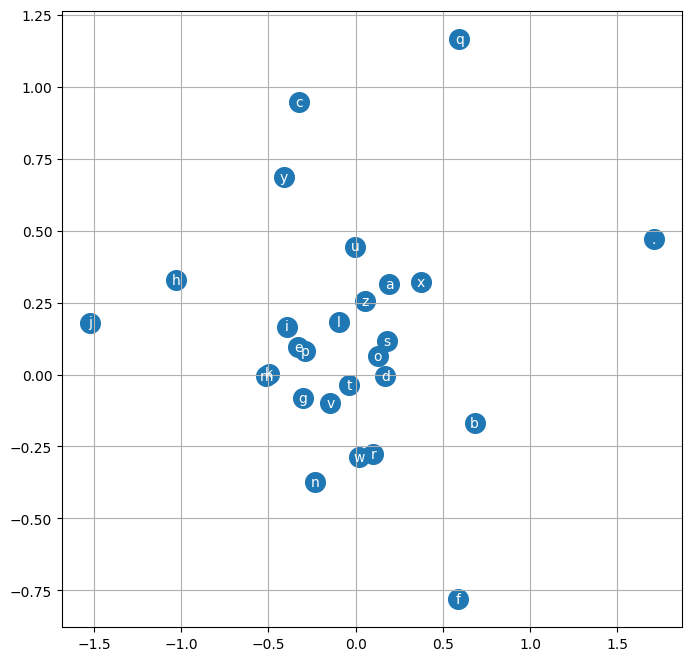

In [93]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [94]:

context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [98]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(10):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
amille.
khi.
mili.
taty.
salaysie.
mahnen.
delynn.
jarqui.
nellara.
